# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Rukky | Nwachukwu | Rukky Nwachukwu, 18th Nov., 2025 | 12 | 25% |
| Member 2: | Fabricio | Amador | Fabricio Amador, 2025-11-18 | 12 | 25% |
| Member 3: | Juan | Quintero | Juan Quintero, 18/11/2025  | 12 | 25% |
| Member 4: | Mina | Al-Kaisi | Mina Al-Kaisi 2025/11/18 | 12 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

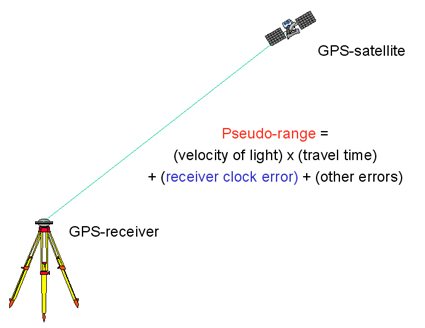

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

pseudoranges_url = "https://raw.githubusercontent.com/Rukkyn678/ENGG680_2025_Fall/refs/heads/main/Lab_Assignment2/pseudoranges.xlsx"
sat_url = "https://raw.githubusercontent.com/Rukkyn678/ENGG680_2025_Fall/refs/heads/main/Lab_Assignment2/satellite_position.xlsx"


df_pseudorange = pd.read_excel(pseudoranges_url)
df_sat_pos = pd.read_excel(sat_url)



# Add small random perturbations in the range (0, 0.5)
np.random.seed(42)  # For reproducible results
# Correctly extract only the pseudorange values from the dataframe and convert to numpy
pseudorange_values = df_pseudorange.iloc[:, 1].to_numpy()
noise = np.random.uniform(0, 0.5, size=pseudorange_values.shape)
pseudorange = pseudorange_values + noise
sat_pos = df_sat_pos.to_numpy() # Original sat_pos with ID, X, Y, Z


# Show a preview
print("Pseudorange (with noise):\n", pseudorange)
print("\nSatellite positions:\n", sat_pos)

Pseudorange (with noise):
 [22919741.14869956 20459894.56315595 22400338.77941037 22829141.21192965
 22342014.89518462 25646454.61429046 23814776.2744646  24311399.75024017
 21353640.44123681 24971609.99147099 20638981.06929275]

Satellite positions:
 [[ 7.00000000e+00  5.28079174e+06 -2.55014601e+07  4.64950829e+06]
 [ 8.00000000e+00 -2.15965605e+06 -2.11160248e+07  1.55979092e+07]
 [ 1.10000000e+01  1.03718522e+07 -2.17131113e+07  1.05586870e+07]
 [ 1.50000000e+01 -1.60857608e+07  4.28507122e+06  2.07420421e+07]
 [ 1.70000000e+01 -1.43129881e+07 -2.20450143e+07  4.67120840e+06]
 [ 1.80000000e+01 -2.43571819e+06  1.62572051e+07  2.10997795e+07]
 [ 1.90000000e+01  1.59124672e+07 -3.46251531e+06  2.10536283e+07]
 [ 2.40000000e+01  1.62718482e+07 -2.18766320e+05  2.10353327e+07]
 [ 2.60000000e+01 -1.92470355e+07 -7.25980368e+06  1.64729819e+07]
 [ 2.70000000e+01 -1.59311520e+07  1.20773673e+07  1.80580768e+07]
 [ 2.80000000e+01 -7.68001411e+06 -1.38554627e+07  2.18429754e+07]]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]   # number of satellites / measurements
m = 4                      # unknowns: x, y, z, and receiver clock bias

In [5]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [6]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    # your code here
    # Vectorized distance computation using numpy
    distance = np.sqrt(np.sum((satellite_pos - receiver_pos)**2, axis=1))
    return distance

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [7]:
n = pseudorange.shape[0]  # number of measurements

P = (1/1.2)*np.identity(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [8]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0]) # Initial guess for [x, y, z, clock_bias]

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [9]:
delta = 10.0  # initial correction value (large to start iterations)
i = 0    # iteration counter

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = []

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [10]:
def design_matrix(receiver_pos, satellite_pos, distance):
    # your code here
    # Extract receiver coordinates (ignore clock bias)
    rx, ry, rz = receiver_pos[:3]

    # Number of satellites
    n = satellite_pos.shape[0]

    # Compute the partial derivatives
    A = np.zeros((n, 4))

    A[:, 0] = (rx - satellite_pos[:, 0]) / distance  # dρ/dx
    A[:, 1] = (ry - satellite_pos[:, 1]) / distance  # dρ/dy
    A[:, 2] = (rz - satellite_pos[:, 2]) / distance  # dρ/dz
    A[:, 3] = -1                                     # dρ/db (clock bias)

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [11]:
threshold = 0.008  # meters for x, y, z
delta = np.array([10.0, 10.0, 10.0, 10.0])  # initial correction as array
# Initial guess
x_hat = x_0 .copy()

# sat_pos has 4 columns (ID + XYZ)
# Correctly extract only the XYZ coordinates from the `sat_pos` numpy array
# which was loaded as (ID, X, Y, Z) in the previous cell.
# Rename to avoid confusion and make its content clear.
sat_coordinates_xyz = sat_pos[:, 1:4]  #keep columns 1, 2, 3 (x, y, z)
print(sat_coordinates_xyz.shape)

print(pseudorange.shape)

while np.linalg.norm(delta[:3]) >= threshold:
       # compute geometric distance
       distance = euclidean_norm(x_hat[:3], sat_coordinates_xyz)

       # compute design matrix
       A = design_matrix(x_hat, sat_coordinates_xyz, distance)

       # compute misclosure
       w = pseudorange - (distance - x_hat[3])

       # compute corrections
       delta = np.linalg.inv(A.T @ P @ A) @ (A.T @ P @ w)

       # update states
       x_hat = x_hat + delta

       # position error
       err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)

       # iteration counter
       i += 1

       # store results
       arr_w.append(w.copy())
       arr_delta.append(delta.copy())
       arr_err_pos.append(err_pos)
       arr_i.append(i)



# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
apv = (w.T @ P @ w) / (n - m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = apv * np.linalg.inv(A.T @ P @ A)



(11, 3)
(11,)


### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [12]:
# your code here
print("===== LSE GNSS Solution Results =====\n")

# 1. Estimated states
print("Estimated States (x, y, z, clock bias):")
print(x_hat)
print()

# 2. Last corrections array
print("Last Corrections (delta):")
print(delta)
print()

# 3. Estimated measurements residuals (last iteration)
print("Residuals (misclosure) of estimated measurements:")
print(arr_w[-1])
print()

# 4. A Posteriori Variance of Unit Weight
print("A Posteriori Variance of Unit Weight:")
print(apv)
print()

# 5. Covariance matrix of estimated states
print("Covariance Matrix of Estimated States:")
print(C_x_hat)
print()

# 6. Number of iterations
print("Number of Iterations to Converge:")
print(arr_i[-1])
print()

# 7. 3D position errors per iteration
print("3D Position Errors per Iteration:")
for iter_idx, err in zip(arr_i, arr_err_pos):
    print(f"Iteration {iter_idx}: Error = {err:.6f} m")


===== LSE GNSS Solution Results =====

Estimated States (x, y, z, clock bias):
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00]

Last Corrections (delta):
[ 3.24288929e-06  6.43165988e-06 -1.77292576e-05  2.09923963e-05]

Residuals (misclosure) of estimated measurements:
[ 0.20483172  0.34240459 -0.98043973  0.06599824  0.0470863  -1.57080159
 -0.30920947  1.69957656  0.33524236  0.74094027 -0.57575024]

A Posteriori Variance of Unit Weight:
0.9013677124182478

Covariance Matrix of Estimated States:
[[ 0.3457467   0.07534978 -0.09147658  0.07903424]
 [ 0.07534978  0.46020454 -0.62851089  0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707 -1.19415431]
 [ 0.07903424  0.3983237  -1.19415431  0.75634562]]

Number of Iterations to Converge:
5

3D Position Errors per Iteration:
Iteration 1: Error = 1165503.207870 m
Iteration 2: Error = 32942.531315 m
Iteration 3: Error = 32.415231 m
Iteration 4: Error = 5.425819 m
Iteration 5: Error = 5.425802 m


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [13]:
# your answer here
'''The LSE solution converged in 5 iterations, with the 3D position error decreasing from over 1.1 million meters initially to about 5.43 meters in the final iteration, showing rapid and effective convergence.
The last corrections were negligible, indicating a stable solution.
However, the a posteriori variance and covariance values are unusually large, suggesting potential issues with measurement scaling or clock bias dominance, so the uncertainties should be interpreted with caution.'''

'The LSE solution converged in 5 iterations, with the 3D position error decreasing from over 1.1 million meters initially to about 5.43 meters in the final iteration, showing rapid and effective convergence.\nThe last corrections were negligible, indicating a stable solution.\nHowever, the a posteriori variance and covariance values are unusually large, suggesting potential issues with measurement scaling or clock bias dominance, so the uncertainties should be interpreted with caution.'

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

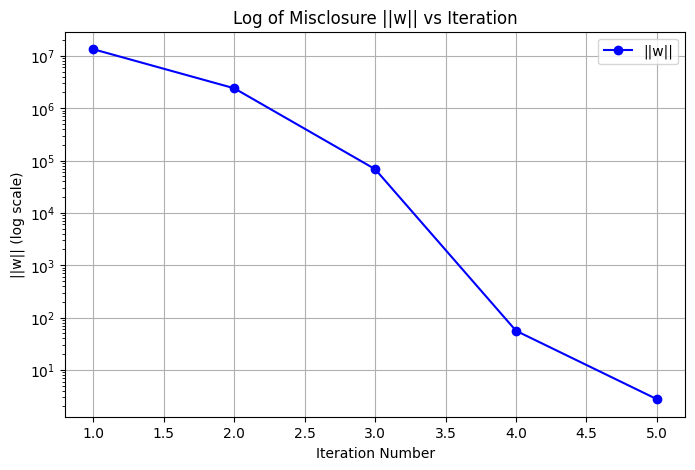

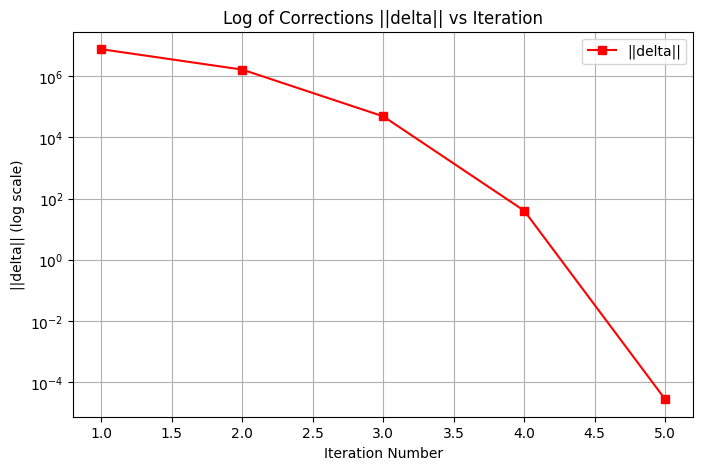

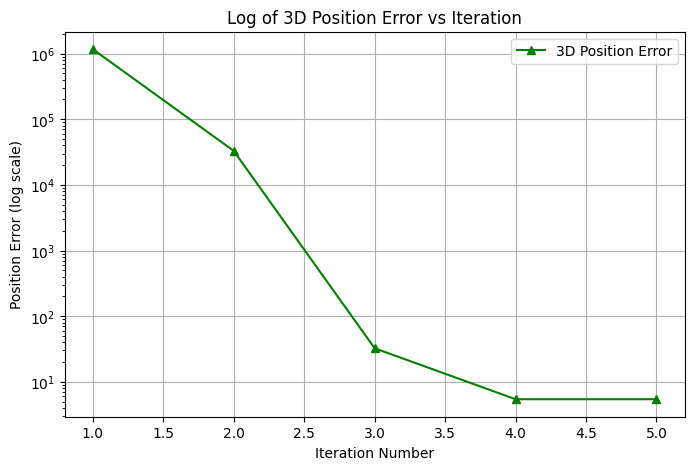

In [14]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(8,5))
plt.plot(arr_i, [np.linalg.norm(w) for w in arr_w], marker='o', color='b', label='||w||')
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('||w|| (log scale)')
plt.title('Log of Misclosure ||w|| vs Iteration')
plt.grid(True)
plt.legend()
plt.show()

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(8,5))
plt.plot(arr_i, [np.linalg.norm(d) for d in arr_delta], marker='s', color='r', label='||delta||')
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('||delta|| (log scale)')
plt.title('Log of Corrections ||delta|| vs Iteration')
plt.grid(True)
plt.legend()
plt.show()

# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(8,5))
plt.plot(arr_i, arr_err_pos, marker='^', color='g', label='3D Position Error')
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Position Error (log scale)')
plt.title('Log of 3D Position Error vs Iteration')
plt.grid(True)
plt.legend()
plt.show()


### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [15]:
# your answer here
'''Across the three plots, you can see a clear pattern of the least-squares solution gradually converging, even though the first two plots show some non-monotonic behaviour.
The misclosure norm ‖w‖ initially decreases, then increases, which suggests that early iterations partially reduce the residuals but later iterations adjust the solution more aggressively, temporarily increasing misclosure as the algorithm moves toward a better overall fit.
A similar pattern appears in the correction norm ‖δ‖, which drops sharply after the first iteration, then grows as the solution refines—this reflects the algorithm taking smaller steps once it is near the basin of convergence and then larger corrective steps as it fine-tunes the state.
In contrast, the 3D position error decreases smoothly by several orders of magnitude, showing that despite fluctuations in residuals and corrections, the estimated receiver position is steadily converging to the true value, which is the behaviour expected of a well-posed nonlinear least-squares GNSS positioning problem.'''

'Across the three plots, you can see a clear pattern of the least-squares solution gradually converging, even though the first two plots show some non-monotonic behaviour.\nThe misclosure norm ‖w‖ initially decreases, then increases, which suggests that early iterations partially reduce the residuals but later iterations adjust the solution more aggressively, temporarily increasing misclosure as the algorithm moves toward a better overall fit.\nA similar pattern appears in the correction norm ‖δ‖, which drops sharply after the first iteration, then grows as the solution refines—this reflects the algorithm taking smaller steps once it is near the basin of convergence and then larger corrective steps as it fine-tunes the state.\nIn contrast, the 3D position error decreases smoothly by several orders of magnitude, showing that despite fluctuations in residuals and corrections, the estimated receiver position is steadily converging to the true value, which is the behaviour expected of a we

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [28]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [29]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
 sat_coordinates_xyz = sat_pos[:, 1:4]
 distances = euclidean_norm(rec_pos, sat_coordinates_xyz)
 predicted = distances - cdT
 residuals = predicted - pseudorange
 L = np.sum(residuals ** 2)
 return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [30]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    # Extract satellite XYZ coordinates
    sat_coordinates_xyz = sat_pos[:, 1:4]

    # Geometric distances ρ
    distances = euclidean_norm(rec_pos, sat_coordinates_xyz)

    # Predicted pseudoranges
    predicted = distances - cdT

    # Residuals: predicted - measured
    residuals = predicted - pseudorange  # shape (n,)

    # Build the design matrix A using the same structure as in the LSE part
    # receiver_state includes [x, y, z, cdT]
    receiver_state = np.hstack([rec_pos, cdT])
    A = design_matrix(receiver_state, sat_coordinates_xyz, distances)  # shape (n,4)

    # Gradient of sum of squared residuals: ∇L = 2 A^T * residuals
    grad = 2 * A.T @ residuals  # shape (4,)
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [31]:

# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.02, max_iters=10000, tolerance=0.0000008):  #It does not converge with learning rate 0.08  We reduced the learning rate to find a solution.

    global steps_count

    #initalize the estimates as zeros
    X = np.array([0, 0, 0, 0])   #X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)

        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [32]:
optimized_params = gradient_descent(pseudorange, sat_pos)

# print the mentioned metrics
print("Optimized parameters [x, y, z, cdT]:")
print(optimized_params)

# final position errors of receiver
pos_err = optimized_params[:3] - GroundTruth
print("\nFinal position errors of receiver (m):")
print(pos_err)

# number of steps taken for convergence
print("\nNumber of steps taken for convergence:")
print(steps_count)

# final cost value
if len(arr_cost) > 0:
    final_cost = arr_cost[-1]
else:
    final_cost = cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal cost value:")
print(final_cost)

# final gradient values
if len(arr_grad) > 0:
    final_grad = arr_grad[-1]
else:
    final_grad = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal gradient values:")
print(final_grad)

Converged !
Optimized parameters [x, y, z, cdT]:
[-1.63349246e+06 -3.65162953e+06  4.95248541e+06 -6.69818687e+00]

Final position errors of receiver (m):
[-3.07590697 -2.3483717   3.79360841]

Number of steps taken for convergence:
1463

Final cost value:
7.571518218781385

Final gradient values:
[ 0.00031299  0.00174393 -0.00535989  0.00303872]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

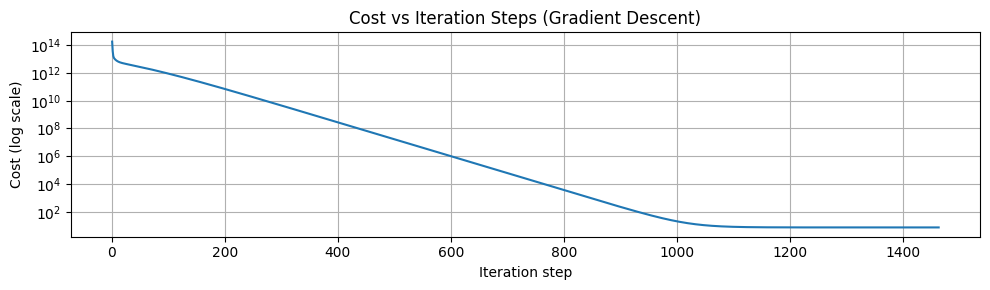

In [33]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
steps = np.arange(1, len(arr_cost) + 1)
ax.semilogy(steps, arr_cost)
ax.set_xlabel("Iteration step")
ax.set_ylabel("Cost (log scale)")
ax.set_title("Cost vs Iteration Steps (Gradient Descent)")
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)

# The cost decreases with each iterations and then
# gradually flattens out, indicating that the algorithm converges to the minimum or closer to 0

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

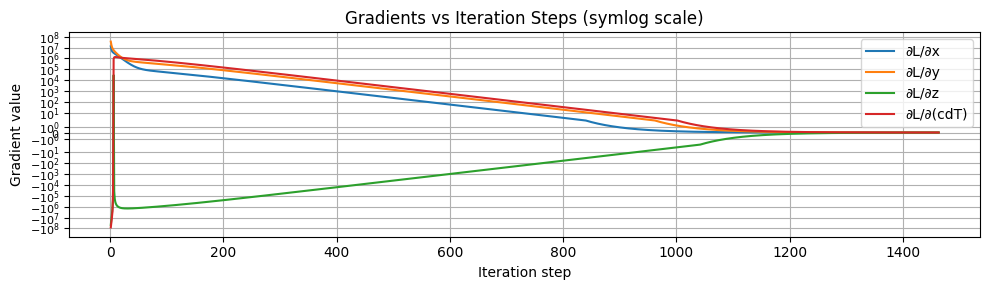

In [34]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
grad_array = np.array(arr_grad)  # shape (k, 4)
steps = np.arange(1, grad_array.shape[0] + 1)

ax.plot(steps, grad_array[:, 0], label="∂L/∂x")
ax.plot(steps, grad_array[:, 1], label="∂L/∂y")
ax.plot(steps, grad_array[:, 2], label="∂L/∂z")
ax.plot(steps, grad_array[:, 3], label="∂L/∂(cdT)")

ax.set_yscale("symlog")
ax.set_xlabel("Iteration step")
ax.set_ylabel("Gradient value")
ax.set_title("Gradients vs Iteration Steps (symlog scale)")
ax.legend()
ax.tick_params(axis='y', labelsize=8)
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# Each gradient start with the initial estimates and converge to a minimum value close to 0, decreasing the gradient with each interaction.

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

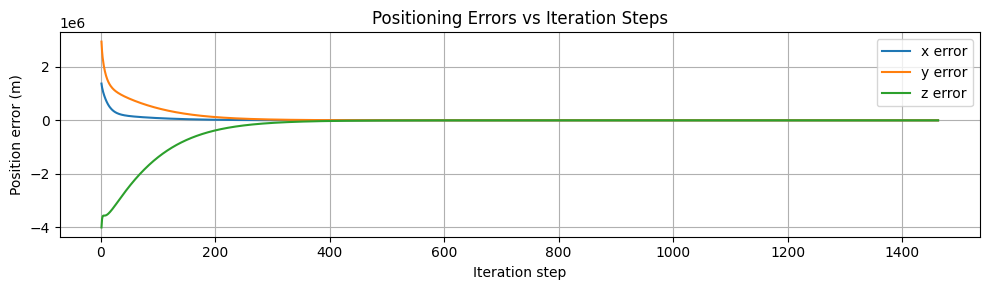

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
err_array = np.array(arr_err)  # shape (k, 3)
steps = np.arange(1, err_array.shape[0] + 1)

ax.plot(steps, err_array[:, 0], label="x error")
ax.plot(steps, err_array[:, 1], label="y error")
ax.plot(steps, err_array[:, 2], label="z error")

ax.set_xlabel("Iteration step")
ax.set_ylabel("Position error (m)")
ax.set_title("Positioning Errors vs Iteration Steps")
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# The overall error of the position decreases with each iteration because the gradient of each variable is also decreasing to find the optimal solution

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [36]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params = gradient_descent(pseudorange, sat_pos, learning_rate=0.008, max_iters=10000, tolerance=0.0000008)

# print the mentioned metrics
print("Optimized parameters [x, y, z, cdT]:")
print(optimized_params)

# final position errors of receiver
pos_err = optimized_params[:3] - GroundTruth
print("\nFinal position errors of receiver (m):")
print(pos_err)

# number of steps taken for convergence
print("\nNumber of steps taken for convergence:")
print(steps_count)

# final cost value
if len(arr_cost) > 0:
    final_cost = arr_cost[-1]
else:
    final_cost = cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal cost value:")
print(final_cost)

# final gradient values
if len(arr_grad) > 0:
    final_grad = arr_grad[-1]
else:
    final_grad = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal gradient values:")
print(final_grad)

# print the metrics
# ...

Converged !
Optimized parameters [x, y, z, cdT]:
[-1.63349246e+06 -3.65162953e+06  4.95248541e+06 -6.69565017e+00]

Final position errors of receiver (m):
[-3.07564569 -2.34691585  3.78913395]

Number of steps taken for convergence:
3590

Final cost value:
7.571562058364636

Final gradient values:
[ 0.00049374  0.00275108 -0.00845526  0.00479358]


In [37]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008, max_iters=100000, tolerance=0.00005)

# print the mentioned metrics
print("Optimized parameters [x, y, z, cdT]:")
print(optimized_params)

# final position errors of receiver
pos_err = optimized_params[:3] - GroundTruth
print("\nFinal position errors of receiver (m):")
print(pos_err)

# number of steps taken for convergence
print("\nNumber of steps taken for convergence:")
print(steps_count)

# final cost value
if len(arr_cost) > 0:
    final_cost = arr_cost[-1]
else:
    final_cost = cost_function(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal cost value:")
print(final_cost)

# final gradient values
if len(arr_grad) > 0:
    final_grad = arr_grad[-1]
else:
    final_grad = gradient(optimized_params[:3], optimized_params[3], sat_pos, pseudorange)
print("\nFinal gradient values:")
print(final_grad)

# print the metrics
# ...

Converged !
Optimized parameters [x, y, z, cdT]:
[-1.63349244e+06 -3.65162944e+06  4.95248512e+06 -6.53270260e+00]

Final position errors of receiver (m):
[-3.05886196 -2.25339734  3.50171238]

Number of steps taken for convergence:
30236

Final cost value:
7.616314712117129

Final gradient values:
[ 0.01221212  0.06804566 -0.2091328   0.11856345]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# your answer here
#Q1
#With a relatively large learning rate the algorithm converges in
#fewer iterations, but the updates are more aggressive and the cost and
#parameter values may oscillate before settling. Reducing the learning
#rate to 0.008 makes the convergence slower but smoother, with more
#gradual changes in the cost and gradients. With an even smaller learning
#rate (0.0008) the algorithm requires many more iterations to reach a
#similar cost, but the trajectory is very stable and the risk of
#overshooting the minimum is reduced

# LSE is using the normal equations (A^T P A)^(-1) A^T P w at each iteration.
# This gives a direct update based on matrix inversion and typically
# converges in a small number of iterations, but it requires computing and
# inverting matrices which can be complicate for large data set problems.

# Gradient Descent, on the other hand, updates the parameters using the
# gradient of the cost function scaled by a learning rate. It
# does not require explicit matrix inversion, but
# its performance depends strongly on the choice of learning rate and may
# need many iterations to converge. In this assignment both methods
# converge to similar receiver coordinates, but LSE reaches the solution
# in fewer iterations, while Gradient Descent gives more control over the
# update size through the learning rate.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the Student Depression Dataset
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'], inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)   # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
# your code here
data = data[data['Gender'] != 'Other']

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
# your code here
print("Shape after preprocessing:", data.shape)
data.head()

Shape after preprocessing: (27898, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression']  # Target vector
X = data.drop(columns=['Depression']) # Feature matrix

# Display sizes of X and y
# your code here
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27898, 16)
y shape: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

In [ ]:
import matplotlib.pyplot as plt

Class counts:
Class 1: 16335 samples
Class 0: 11563 samples


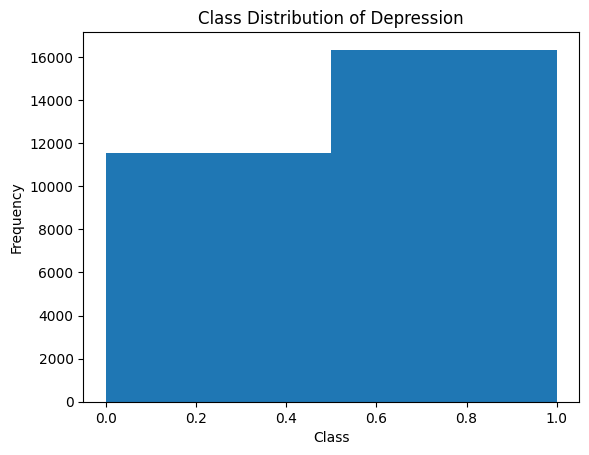

In [ ]:
# Check the class distribution of y
plt.hist(y, bins=len(y.unique()))
plt.title("Class Distribution of Depression")
plt.xlabel("Class")
plt.ylabel("Frequency")

# Display exact values for each bin in the histogram
# hint: Use for loop
# your code here
print("Class counts:")
class_counts = y.value_counts()

for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples")


plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
_, X_small, _, y_small = train_test_split(
    X, y, test_size=0.03, random_state=42, stratify=y
)

# Display sizes of X_small and y_small (0.5 marks)
print("X_small shape:", X_small.shape)
print("y_small shape:", y_small.shape)

X_small shape: (837, 16)
y_small shape: (837,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import pandas as pd

# Note: 70% training set, 30% testing set
# Create a function that calculates all required information
def run_experiment(X_data, y_data):
    # Train/test split (random_state = 0 as required)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=0, stratify=y_data
    )

    # Instantiate model
    model = LogisticRegression(max_iter=2000)

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)

    # Metrics
    data_size = len(X_data)
    n_train = len(X_train)
    n_test = len(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    ll = log_loss(y_test, y_test_proba)

    # Return everything we need
    return data_size, n_train, n_test, train_acc, test_acc, ll


# Step 3 & 4: three different datasets
# ------------------------------------

# Test 1: Full dataset (X and y)
data_size_1, n_train_1, n_test_1, train_acc_1, test_acc_1, ll_1 = run_experiment(X, y)

# Test 2: Only first two columns of X and y
X_two = X.iloc[:, :2]
data_size_2, n_train_2, n_test_2, train_acc_2, test_acc_2, ll_2 = run_experiment(X_two, y)

# Test 3: Small dataset (X_small and y_small)
data_size_3, n_train_3, n_test_3, train_acc_3, test_acc_3, ll_3 = run_experiment(X_small, y_small)


# Step 5.1: Results DataFrame
# ------------------------------------

results = pd.DataFrame(
    {
        "Data size":         [data_size_1, data_size_2, data_size_3],
        "Training samples":  [n_train_1,   n_train_2,   n_train_3],
        "Testing samples":   [n_test_1,    n_test_2,    n_test_3],
        "Training accuracy": [train_acc_1, train_acc_2, train_acc_3],
        "Testing accuracy":  [test_acc_1,  test_acc_2,  test_acc_3],
        "Log loss":          [ll_1,        ll_2,        ll_3],
    },
    index=["Full X,y", "First 2 cols", "3% subset"]
)

print(results)


              Data size  Training samples  Testing samples  Training accuracy  \
Full X,y          27898             19528             8370           0.845760   
First 2 cols      27898             19528             8370           0.631811   
3% subset           837               585              252           0.842735   

              Testing accuracy  Log loss  
Full X,y              0.847909  0.350493  
First 2 cols          0.633931  0.652386  
3% subset             0.869048  0.324059  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

# Train logistic regression model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Retrieve target vector and predictions for test set
y_test_true = y_test
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]   # probability of class 1

print("True test labels (y_test):")
print(y_test_true.head())

print("\nPredicted test labels (y_pred):")
print(y_test_pred[:10])

print("\nPredicted probabilities (y_proba):")
print(y_test_proba[:10])

True test labels (y_test):
10438    0
27792    0
10104    1
19515    0
23824    1
Name: Depression, dtype: int64

Predicted test labels (y_pred):
[0 0 1 0 1 1 1 1 1 1]

Predicted probabilities (y_proba):
[0.19050588 0.03891863 0.72252403 0.05744201 0.86332513 0.8547881
 0.975178   0.83297664 0.76255525 0.76181934]


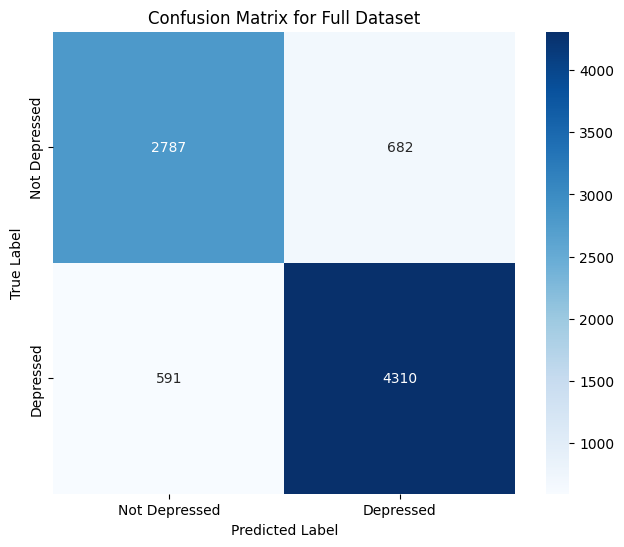

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test_true, y_test_pred)


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_mat,
    xticklabels=['Not Depressed', 'Depressed'],
    yticklabels=['Not Depressed', 'Depressed'],
    square=True,
    annot=True,
    cbar=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Full Dataset")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print(classification_report(y_test_true, y_test_pred, target_names=['Not Depressed', 'Depressed']))


               precision    recall  f1-score   support

Not Depressed       0.83      0.80      0.81      3469
    Depressed       0.86      0.88      0.87      4901

     accuracy                           0.85      8370
    macro avg       0.84      0.84      0.84      8370
 weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 70/30 split (same as earlier)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

# Initialize models (0.5 marks)
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():

    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    y_pred = model_instance.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    model_results[name] = acc

    # Print results
    print(f"{name}: Accuracy = {acc:.4f}")


Logistic Regression: Accuracy = 0.8479
Naive Bayes: Accuracy = 0.6465
KNN: Accuracy = 0.7538


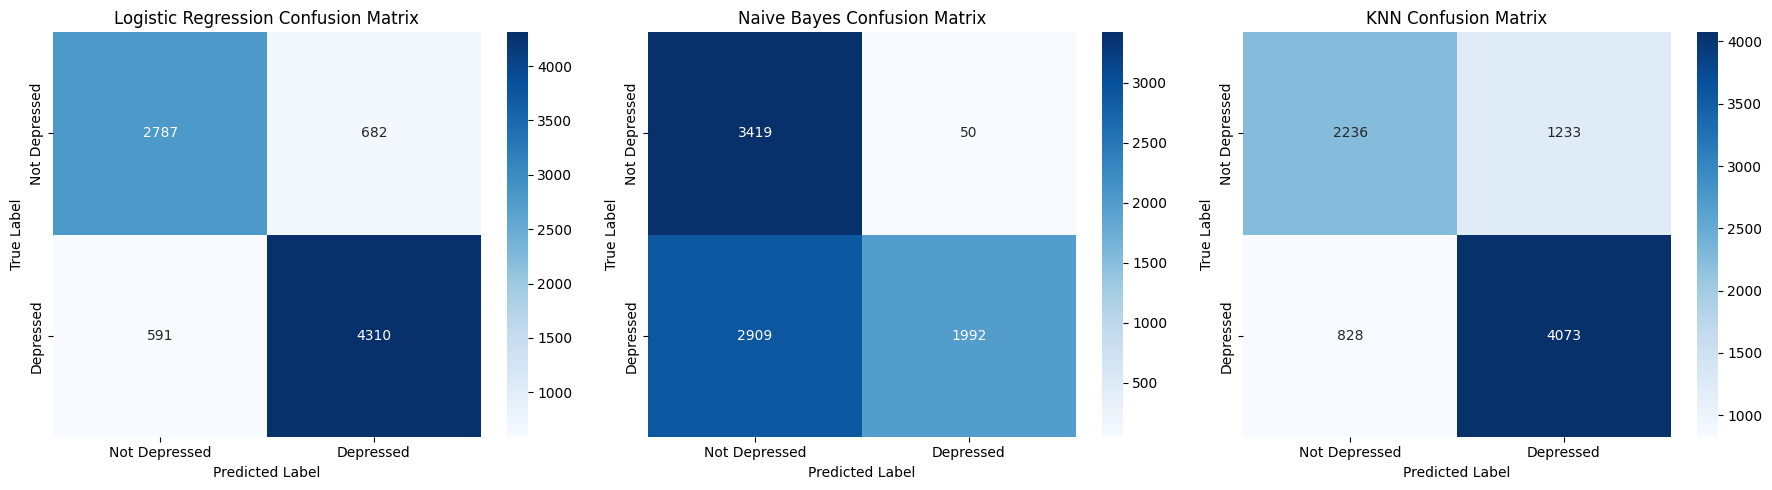

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Dictionary to store confusion matrices
conf_mats = {}

# Compute confusion matrix for each model
for name, model_instance in models.items():

    # Predict again (in case)
    y_pred = model_instance.predict(X_test)

    # Compute confusion matrix
    conf_mats[name] = confusion_matrix(y_test, y_pred)

# Plot all confusion matrices
plt.figure(figsize=(18, 5))

for i, (name, conf_mat) in enumerate(conf_mats.items(), 1):
    plt.subplot(1, 3, i)
    sns.heatmap(
        conf_mat,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Depressed', 'Depressed'],
        yticklabels=['Not Depressed', 'Depressed']
    )
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()


### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)
1. Is the dataset balanced? Does it affect model performance?

   The dataset is imbalanced, with “Not Depressed” cases occurring far more often than “Depressed” cases. This skews the model toward predicting the majority class, which can make accuracy look high but reduces recall for the Depressed group. As a result, the model may miss more actual cases of depression.

2. Does the model overfit or underfit for each of the 3 cases?

   Full dataset (X and y):
    Minimal overfitting or underfitting. Training and testing accuracy are similar.

   First two columns only:
    The model underfits because it lacks enough features to learn meaningful patterns.

   3% subset (X_small and y_small):
    The model overfits due to limited data. Training accuracy increases but testing accuracy decreases.

3. How do training and testing accuracy change depending on data amount?

    Full dataset: High training and high testing accuracy → best generalization.

    Two features only: Reduced training/testing accuracy → underfitting.

    3% subset: High training but lower testing accuracy → overfitting.

    More data improves stability and generalization. Less data or fewer features reduce performance.

4. What do a false positive and false negative represent? Which is worse?

    False Positive (FP): Predicting Depressed when the student is Not Depressed.

    False Negative (FN): Predicting Not Depressed when the student is Depressed.

    A false negative is worse because an actual depressed student goes undetected and may not receive support.

5. Should you maximize precision or recall? How?

    Because false negatives are more harmful, we should maximize recall.
    This can be done by:

    Lowering the classification threshold,

    Using class_weight='balanced',

    Applying oversampling (e.g., SMOTE) to increase minority representation.

6. What does log loss show for the 3 cases?

    Full dataset: Lowest log loss → most accurate and confident predictions.

    Two-feature model: Higher log loss → underfitting and weak probability estimates.

    3% subset: Highest log loss → overfitting and unstable probability predictions.

    Differences arise from variations in data quantity and feature richness.

7. Compare Logistic Regression, Naive Bayes, and KNN. Which performs best and why?

    Logistic Regression: Best overall; stable, robust, and well-suited for structured data.

    Naive Bayes: Lower accuracy due to the unrealistic independence assumption.

    KNN: Moderate performance; sensitive to imbalance and high dimensionality.

    Best model: Logistic Regression, due to strong generalization and appropriate assumptions for the dataset.


# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# Mount Google Drive to access dataset files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:

# Load MNIST dataset from CSV files
#
train_csv_path = "/content/drive/MyDrive/ColabData/mnist_train.csv"
test_csv_path = "/content/drive/MyDrive/ColabData/mnist_test.csv"

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)



Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


Let's visualize some sample images to understand what our models will be learning from.

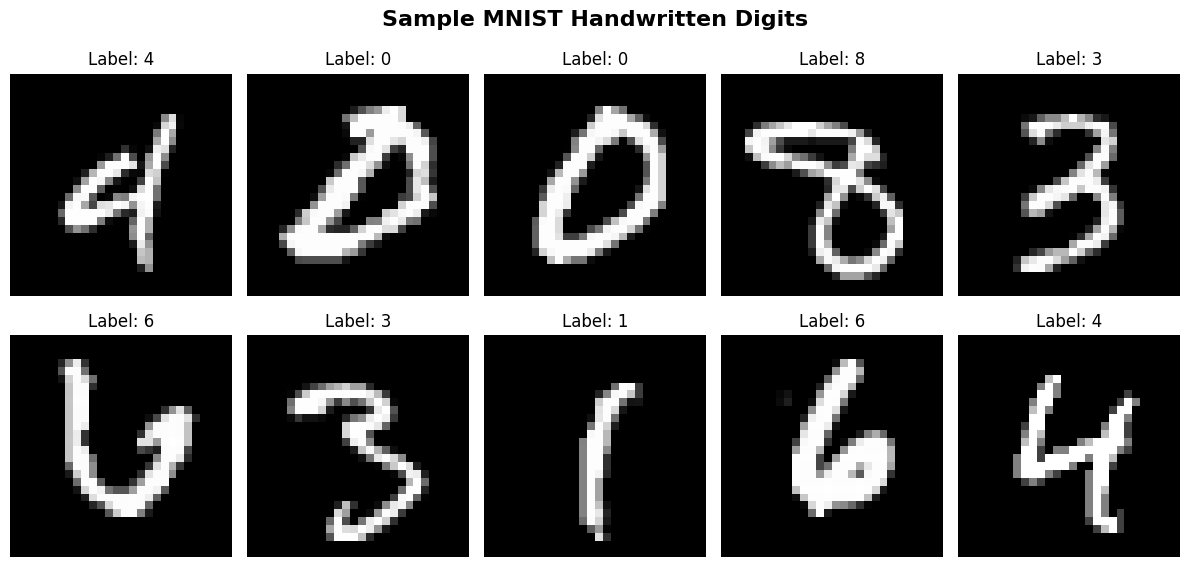

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
from tensorflow.keras.utils import to_categorical
num_classes = 10
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)


# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)


# Display Results
print("=== Model Performance on Test Set ===")
print(f"MLP Test Accuracy: {mlp_test_accuracy:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")




=== Model Performance on Test Set ===
MLP Test Accuracy: 0.9739
CNN Test Accuracy: 0.9898


Performance comparison visualization

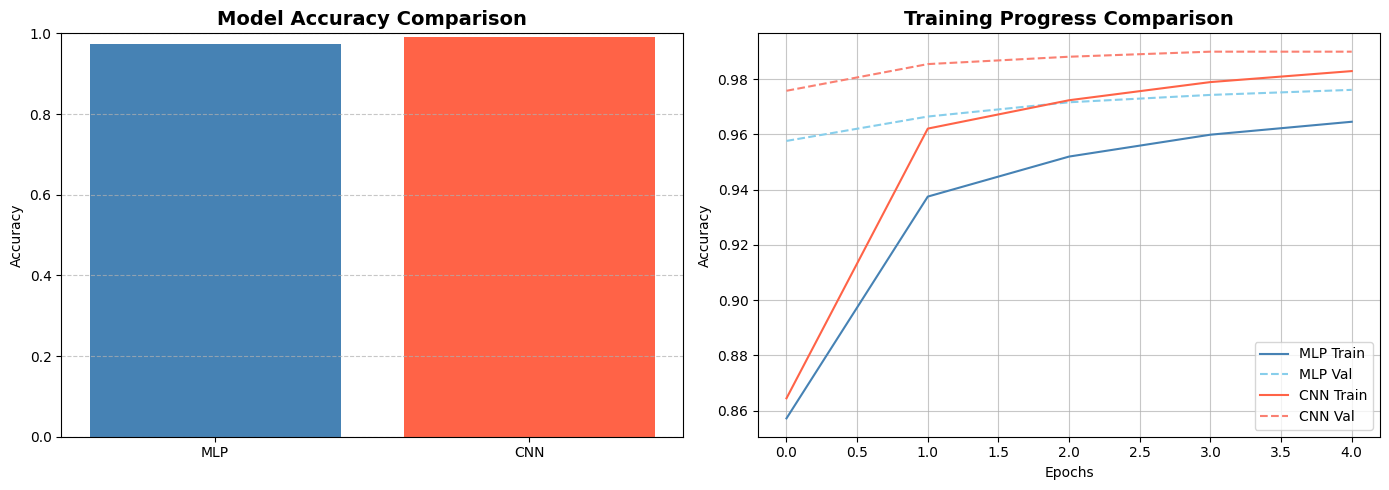

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparing test accuracy
axes[0].bar(['MLP', 'CNN'], [mlp_test_accuracy, cnn_test_accuracy], color=['steelblue', 'tomato'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Line plot showing training vs validation accuracy
axes[1].plot(mlp_history.history['accuracy'], label='MLP Train', color='steelblue')
axes[1].plot(mlp_history.history['val_accuracy'], label='MLP Val', color='skyblue', linestyle='--')
axes[1].plot(cnn_history.history['accuracy'], label='CNN Train', color='tomato')
axes[1].plot(cnn_history.history['val_accuracy'], label='CNN Val', color='salmon', linestyle='--')

axes[1].set_title('Training Progress Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.7)

plt.tight_layout()

plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

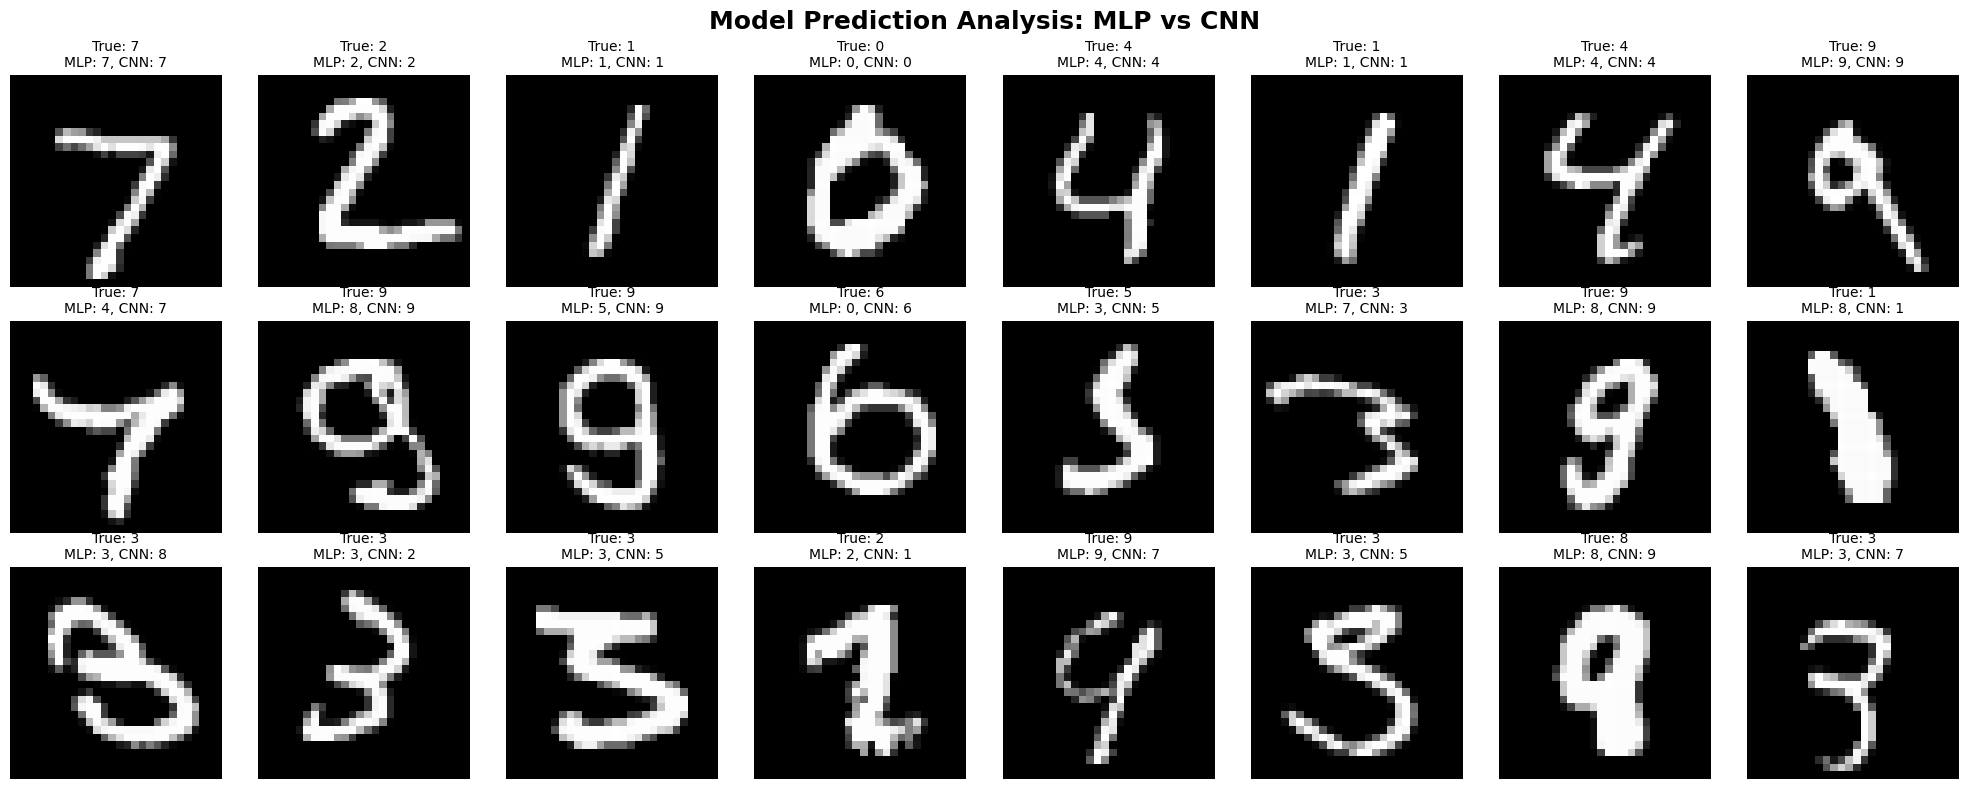

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Model Prediction Analysis: MLP vs CNN', fontsize=18, fontweight='bold')


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]


# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)
rows = [
    ('Both Correct', both_correct_indices),
    ('CNN Correct, MLP Wrong', cnn_correct_mlp_wrong_indices),
    ('MLP Correct, CNN Wrong', mlp_correct_cnn_wrong_indices)
]

for row_idx, (title, indices) in enumerate(rows):
    for col_idx, idx in enumerate(indices):
        ax = axes[row_idx, col_idx]
        ax.imshow(X_test[idx], cmap='gray')
        true_label = y_test[idx]
        mlp_pred = mlp_predicted_classes[idx]
        cnn_pred = cnn_predicted_classes[idx]
        ax.set_title(f'True: {true_label}\nMLP: {mlp_pred}, CNN: {cnn_pred}', fontsize=10)
        ax.axis('off')
    # Add a row label on the left side
    axes[row_idx, 0].set_ylabel(title, fontsize=12, fontweight='bold')

plt.tight_layout()








plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
1. Answer: The CNN Model performed better because it can learn spatial hierarchies and recognize features like edges, curve and spakers. In the other hand, MLP consider every pixel independently. Futhermore, CNN obtain higher accuracy by exploiting spatial structure of images.

2. Answer: In the CNN model, the training and validation accuracy curve rise faster and stabilize higher than MLP. MLP curve usually shoe a slower convergence and larger gaps between training and validation.

3. Answer: The accuracy imporvement indicate how much CNN model generalizes to unseen data compared to MLP Model. Even lower percentages of improvement represent a significant performance when scaled to large datasets or real world applications.

4. The reason is due to MNIST dataset is clean and standardized. Sometime digits are centered and manage grayscale. Futhermore, models can learn the key visuals patterns in few epochs. In response to that, additional training offers a decreased returns and may cause overfitting.

5. Answer: For complex and not grayscale images (color), the MLP wouldn't performe properly since it ingnores spatial patterns. It is possible that CNN still work better but it might need more data, arguments, architecture and longer training to identify complex textures.
